In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("data/ethiopia.csv")
df.head()
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000


The dataset contains 4,108 observations spanning 2015 to 2026, providing a multi-year view of climate conditions.
The mean temperature (T2M) is approximately 16.1°C, indicating a generally moderate climate. The difference between maximum (23.2°C) and minimum (10.2°C) temperatures shows a clear daily and seasonal variation.
The temperature range (T2M_RANGE) has a mean of ~13°C, suggesting significant daily fluctuations between daytime and nighttime temperatures. The relatively high standard deviation confirms noticeable variability across observations.Precipitation has a low mean (3.63) but a very high standard deviation (6.29), indicating a highly skewed distribution with irregular rainfall events. The maximum value (82.3) shows that while most days have little or no rainfall, occasional heavy rainfall events occur.Average wind speed is relatively low (~2.0 m/s) with a maximum of 4.13 m/s, showing generally calm wind conditions. However, variability exists as shown by the standard deviation, indicating occasional wind peaks.

In [5]:
df.duplicated().sum() 

np.int64(0)

In [6]:
df = df.replace(-999, np.nan)

In [7]:
df["Country"] = "Ethiopia"
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [10]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [11]:
df["Month"] = df["DATE"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


In [12]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [10]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M"]

z = df[cols].apply(zscore)
outliers = (abs(z) > 3)

outliers.sum()

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
dtype: int64

In [13]:
df.isnull().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

no missing values

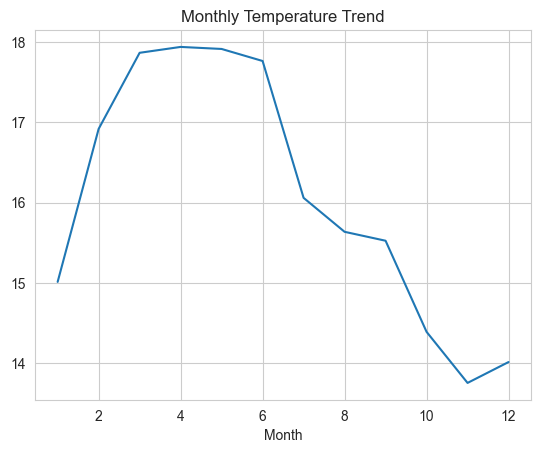

In [11]:
df.groupby("Month")["T2M"].mean().plot()
plt.title("Monthly Temperature Trend")
plt.show()

Third month is the hottest month
11th month is the coolest month.

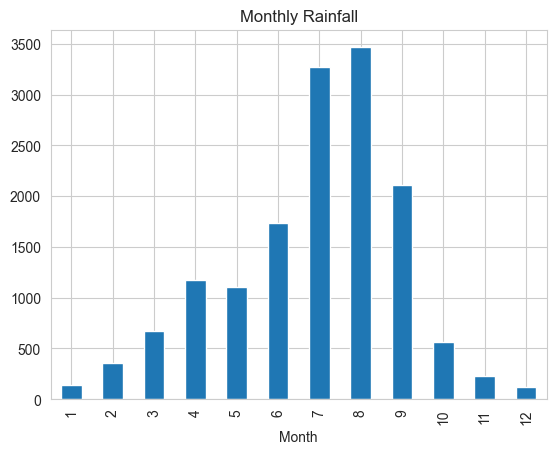

In [17]:
df.groupby("Month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

The 8th month is the pick rainy season.

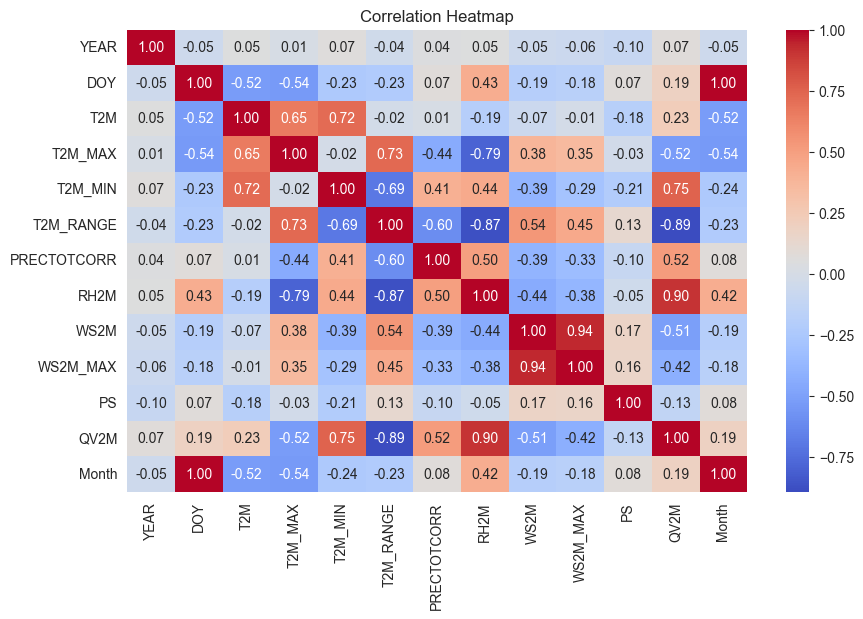

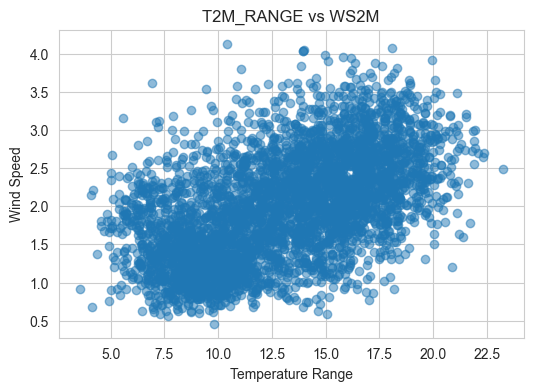

DOY    Month       0.996557
Month  DOY         0.996557
WS2M   WS2M_MAX    0.940826
dtype: float64


In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.show()
corr_unstacked = corr.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1]  # remove self-correlation
top_3 = corr_unstacked.sort_values(ascending=False).head(3)
print(top_3)

DOY and Month (r ≈ 0.9966)
There is an almost perfect positive correlation between Day of Year (DOY) and Month. This is expected because both variables represent time progression, where Month is derived directly from DOY.
WS2M and WS2M_MAX (r ≈ 0.9408)
A very strong positive correlation exists between average wind speed (WS2M) and maximum wind speed (WS2M_MAX).This suggests that wind patterns in Ethiopia are stable and predictable, with periods of stronger winds affecting both average and maximum values similarly.

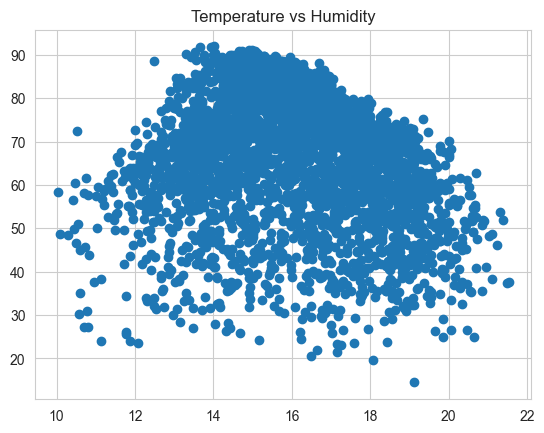

In [14]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.show()

In [ ]:
df.to_csv("data/ethiopia_clean.csv", index=False)

# Ethiopia Climate Data EDA

This notebook explores climate patterns in Ethiopia using NASA dataset data.  
